In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\Parth Patel\Downloads\csvdata.csv")
df.head()

,Unnamed: 0,City,Price,Area,Location,No. of Bedrooms
0,0,Bangalore,30000000,3340,JP Nagar Phase 1,4
1,1,Bangalore,7888000,1045,Dasarahalli on Tumkur Road,2
2,2,Bangalore,4866000,1179,Kannur on Thanisandra Main Road,2
3,3,Bangalore,8358000,1675,Doddanekundi,3
4,4,Bangalore,6845000,1670,Kengeri,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29135 entries, 0 to 29134
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       29135 non-null  int64 
 1   City             29135 non-null  object
 2   Price            29135 non-null  int64 
 3   Area             29135 non-null  int64 
 4   Location         29135 non-null  object
 5   No. of Bedrooms  29135 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 1.3+ MB


In [4]:
df.describe()

,Unnamed: 0,Price,Area,No. of Bedrooms
count,29135.000000,2.913500e+04,29135.000000,29135.000000
mean,3058.808238,1.195267e+07,1301.816475,2.421074
std,1923.174050,2.387647e+07,767.862339,0.821016
min,0.000000,2.000000e+06,200.000000,1.000000
25%,1431.000000,4.179999e+06,870.000000,2.000000
50%,2891.000000,6.884999e+06,1137.000000,2.000000
75%,4539.500000,1.230000e+07,1504.000000,3.000000
max,7718.000000,8.546000e+08,16000.000000,9.000000


In [5]:
df.dtypes

Unnamed: 0          int64
City               object
Price               int64
Area                int64
Location           object
No. of Bedrooms     int64
dtype: object

In [6]:
df.isnull().sum()

Unnamed: 0         0
City               0
Price              0
Area               0
Location           0
No. of Bedrooms    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates()
df.shape

(29135, 6)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

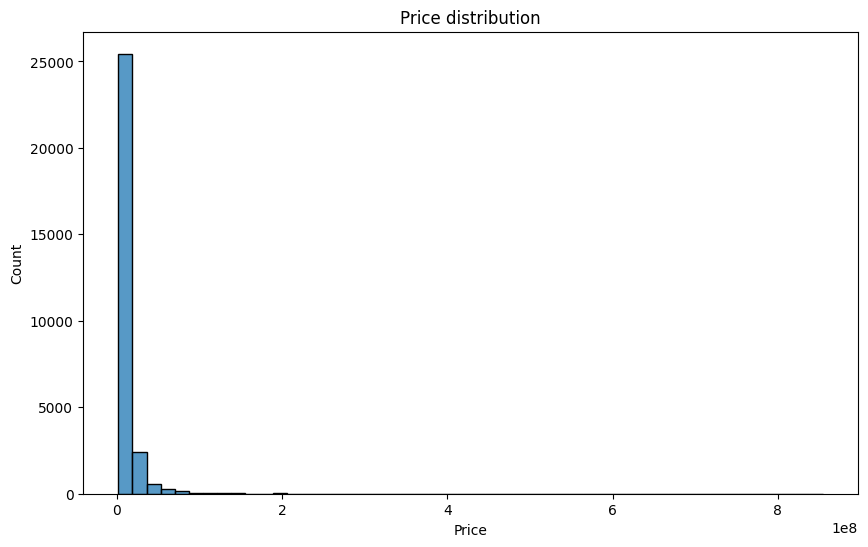

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df["Price"], bins = 50)
plt.title("Price distribution")
plt.show()

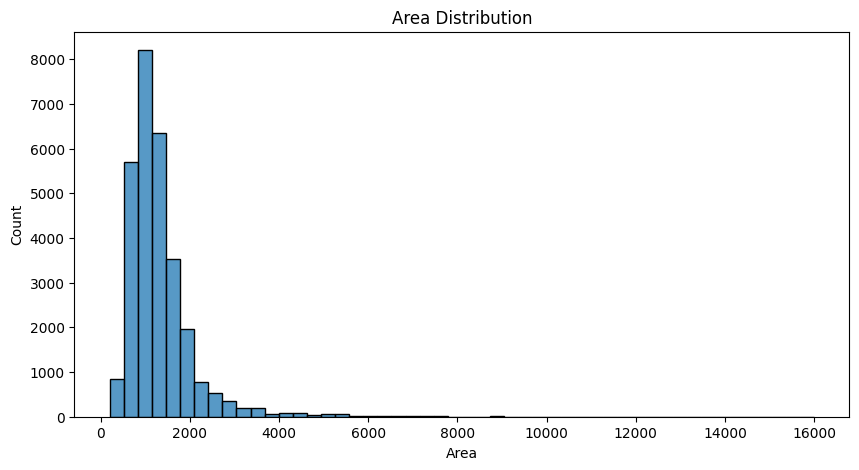

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df["Area"], bins=50)
plt.title("Area Distribution")
plt.show()

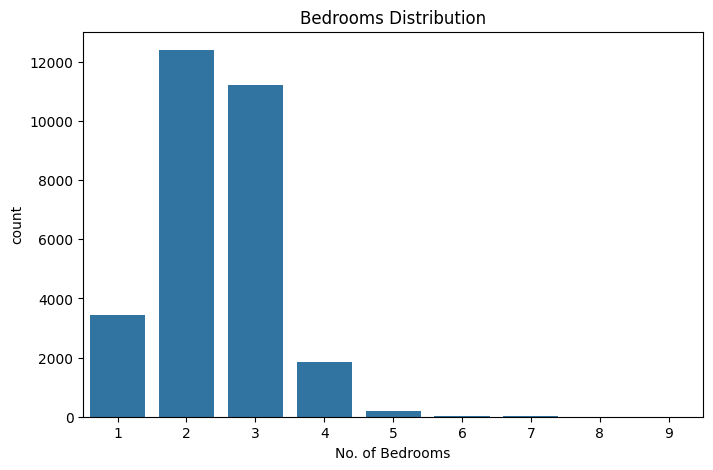

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="No. of Bedrooms", data = df)
plt.title("Bedrooms Distribution")
plt.show()

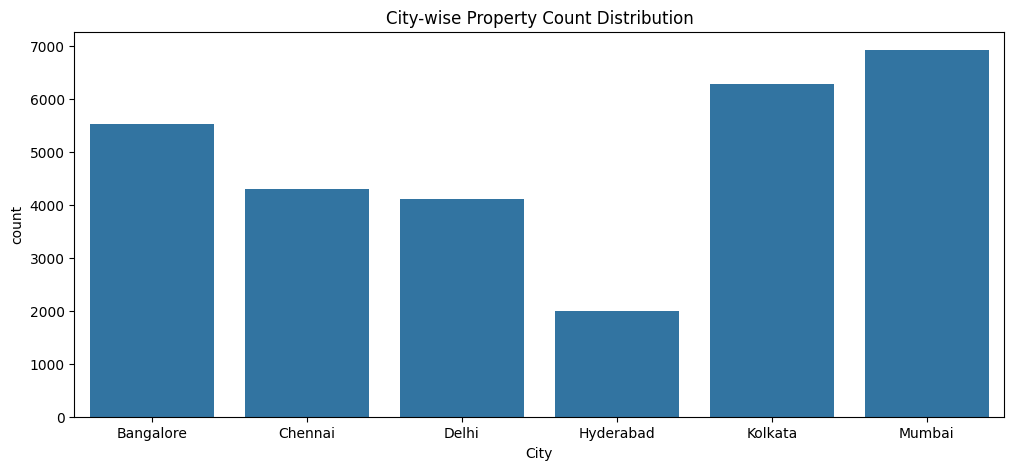

In [13]:
plt.figure(figsize=(12,5))

sns.countplot(x="City", data=df)

plt.title("City-wise Property Count Distribution")

plt.show()

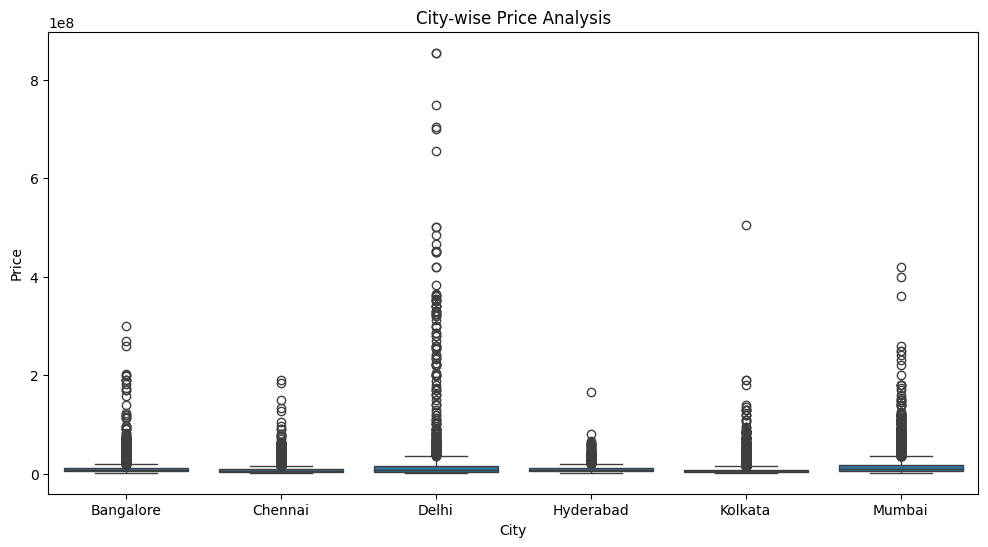

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(x='City', y='Price', data=df)
plt.title("City-wise Price Analysis")
plt.show()

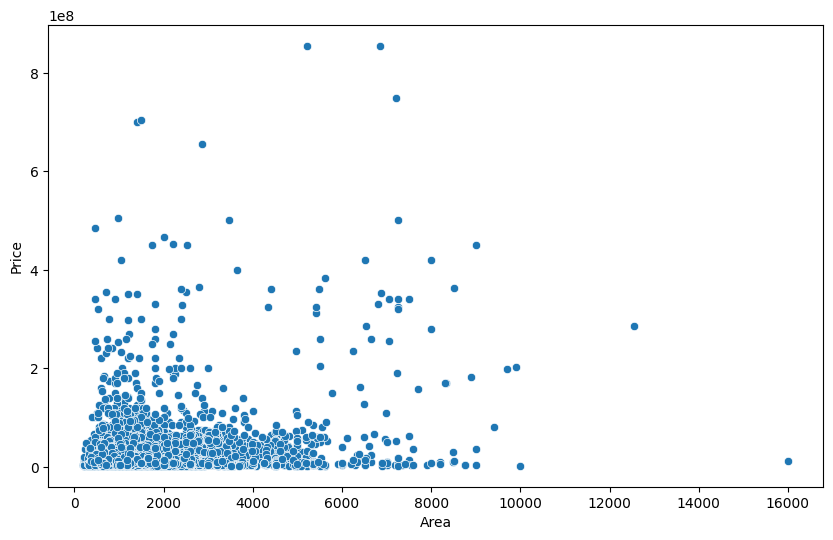

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="Area", y="Price",data=df)

plt.show()

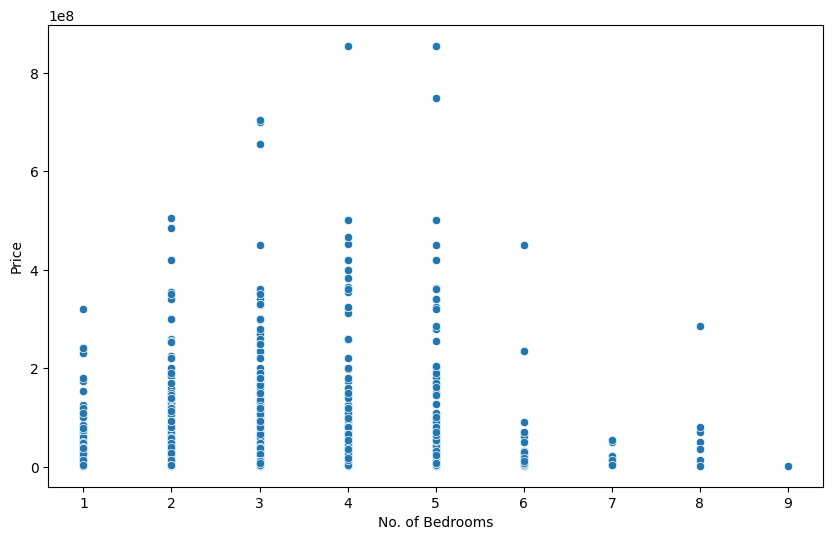

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(x="No. of Bedrooms",y="Price",data=df)

plt.show()

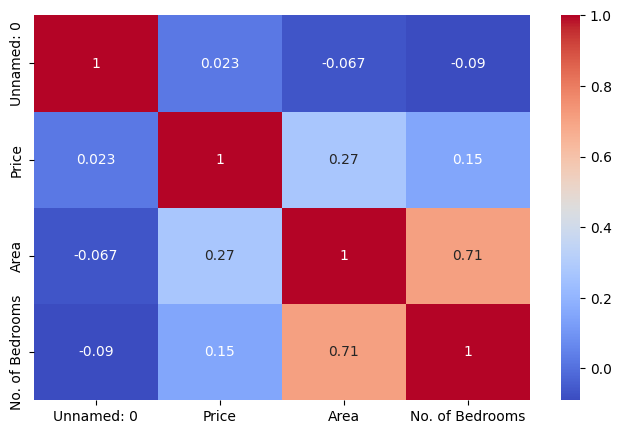

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.show()

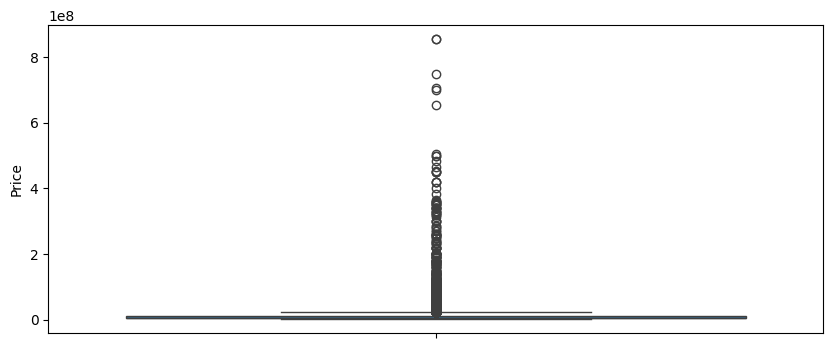

In [18]:
plt.figure(figsize=(10,4))

sns.boxplot(df["Price"])

plt.show()

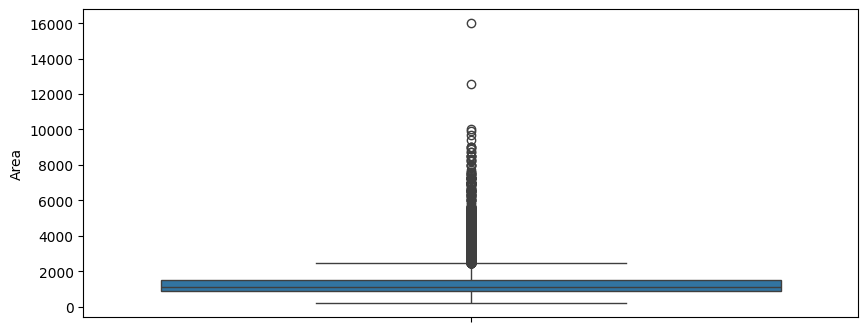

In [19]:
plt.figure(figsize=(10,4))

sns.boxplot(df["Area"])

plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [21]:
df = df.drop(columns=["Unnamed: 0"])

In [22]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [23]:
X = pd.get_dummies(X,columns=["City", "Location"],drop_first=True)

In [24]:
X.head(30)

,Area,No. of Bedrooms,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Location_10 Sector Dwarka,Location_15th Road,Location_200 Feet Radial Road,...,Location_tambaram west,Location_thakur village kandivali east,Location_ulhasnagar 4,Location_vasant vihar thane west,Location_vikaspuri,Location_vile parle west,Location_vrindavan society,Location_west venkatapuram,Location_worli sea Fase,Location_worli sea face
0,3340,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1045,2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1179,2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1675,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1670,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1220,2,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,2502,4,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,1438,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,1405,3,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,660,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
feature_columns = X.columns

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
lr_pred = lr.predict(X_test)
print(lr_pred)

[ 5649996.26292314 16214546.55101369 15332042.15981752 ...
 13861739.9994182   7234917.75678026  7527737.83394181]


In [28]:
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_mse = mean_squared_error(y_test,lr_pred)
lr_r2 = r2_score(y_test,lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 7930299.13115167
Linear Regression MSE: 653348103493734.2
Linear Regression R2: 0.11974324441564088


In [29]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
dt_pred = dt.predict(X_test)

In [31]:
dt_mae = mean_absolute_error(y_test,dt_pred)
dt_mse = mean_squared_error(y_test,dt_pred)
dt_r2 = r2_score(y_test,dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree R2:", dt_r2)

Decision Tree MAE: 8372083.08525007
Decision Tree MSE: 801551939740015.2
Decision Tree R2: -0.07993197827452203


In [32]:
rf = RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42)

rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_pred = rf.predict(X_test)

In [34]:
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 7981405.31244802
Random Forest MSE: 671367904492443.6
Random Forest R2: 0.0954651429279677


In [35]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [36]:
gb_pred = gb.predict(X_test)

In [37]:
gb_mae = mean_absolute_error(y_test,gb_pred)
gb_mse = mean_squared_error(y_test,gb_pred)
gb_r2 = r2_score(y_test,gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting MAE: 7921058.108814321
Gradient Boosting MSE: 634557446908226.9
Gradient Boosting R2: 0.14505992064506423


In [38]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree","Random Forest","Gradient Boosting"],
    "Mean Absolute Error":[lr_mae,dt_mae,rf_mae,gb_mae],
    "Mean Squared Error":[lr_mse,dt_mse,rf_mse,gb_mse],
    "R2 Score":[lr_r2,dt_r2,rf_r2,gb_r2]
})

comparison

,Model,Mean Absolute Error,Mean Squared Error,R2 Score
0,Linear Regression,7.930299e+06,6.533481e+14,0.119743
1,Decision Tree,8.372083e+06,8.015519e+14,-0.079932
2,Random Forest,7.981405e+06,6.713679e+14,0.095465
3,Gradient Boosting,7.921058e+06,6.345574e+14,0.145060


In [39]:
comparison.sort_values(by="R2 Score",ascending=False)

,Model,Mean Absolute Error,Mean Squared Error,R2 Score
3,Gradient Boosting,7.921058e+06,6.345574e+14,0.145060
0,Linear Regression,7.930299e+06,6.533481e+14,0.119743
2,Random Forest,7.981405e+06,6.713679e+14,0.095465
1,Decision Tree,8.372083e+06,8.015519e+14,-0.079932


In [40]:
feature_df = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_
})

feature_df = feature_df.sort_values(by="Importance",ascending=False
)

feature_df.head(20)

,Feature,Importance
0,Area,0.378662
1544,Location_Sunder Nagar,0.089764
1307,Location_Saket,0.052491
1,No. of Bedrooms,0.048845
511,Location_Greater Kailash,0.041283
709,Location_Karampura,0.030585
3,City_Delhi,0.027636
850,Location_MG Road,0.023214
1410,Location_Sector 4 Dwarka,0.022508
1091,Location_Om Enclave Mithapur Extension,0.020901


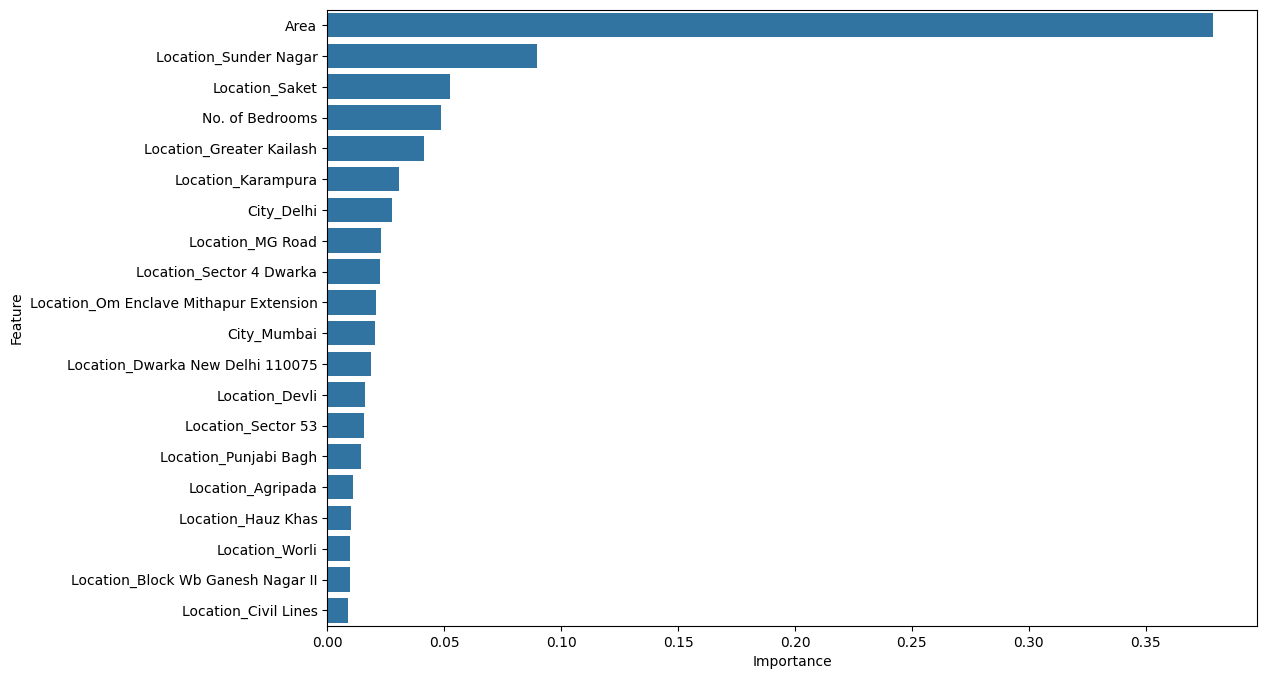

In [41]:
plt.figure(figsize=(12,8))

sns.barplot(x="Importance",y="Feature",data=feature_df.head(20)
)

plt.show()

In [42]:
import pickle

In [49]:
import joblib

joblib.dump(rf,open("house_price_model.pkl","wb"),compress=9)

In [50]:
pickle.dump(feature_columns,open("feature_columns.pkl","wb"))

In [51]:
import os

print(os.getcwd())

C:\Users\Parth Patel
